# Predicting TikTok 30-Day View Counts

Forecast the cumulative view count a video reaches at day 30, using only the first
five days of engagement. Scored by RMSE.

**Data** — three tables, ~6M rows total:

| table | rows | contents |
|---|---|---|
| `videos` | 209,543 | metadata, topic, music, emotion scores |
| `creator_daily` | 278,433 | daily follower / favourite counts per creator |
| `engagement_daily` | 6,068,955 | daily cumulative views, likes, shares, ... |

Only 73,940 videos have a day-30 observation, so those are the modelling universe.

In [1]:
import json
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import nnls
from scipy.stats import spearmanr
from sklearn.model_selection import KFold

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

# folder holding creator_daily.csv / engagement_daily.csv / videos.csv
RAW = next(p for p in [
    Path(r"C:\Users\Admin\Documents\WCD_DataScience_Bootcamp"
         r"\generial metiral and project stuff\data\Tiktok_Dataset"),
    Path("data"), Path("/kaggle/input"),
] if (p / "engagement_daily.csv").exists())
SEED, CUTOFF, N_TEST = 42, 5, 3001
rmse = lambda a, b: float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

## 1. Load and inspect

The first question that matters: are the daily counts *incremental* or *cumulative*?
The answer changes the entire problem.

In [2]:
METRICS = ["play_count", "like_count", "comment_count", "share_count",
           "collect_count", "download_count", "whatsapp_share_count"]
SHORT = {"play_count": "play", "like_count": "like", "comment_count": "cmt",
         "share_count": "shr", "collect_count": "col", "download_count": "dl",
         "whatsapp_share_count": "wa"}

eng = pd.read_csv(RAW / "engagement_daily.csv").sort_values(["video_id", "days_since_post"])
mono = eng.groupby("video_id").play_count.apply(lambda s: s.is_monotonic_increasing)
print(f"rows {len(eng):,} | videos {eng.video_id.nunique():,}")
print(f"play_count non-decreasing for {mono.mean():.1%} of videos -> counts are CUMULATIVE")
eng.head()

rows 6,068,955 | videos 209,543
play_count non-decreasing for 99.4% of videos -> counts are CUMULATIVE


,video_id,date,days_since_post,play_count,like_count,comment_count,share_count,collect_count,download_count,whatsapp_share_count
0,7381889522268654890,2024-06-25,0,1737,26,0,0,0,0,0
1,7381889522268654890,2024-06-26,1,1772,28,0,0,0,0,0
2,7381889522268654890,2024-06-27,2,1778,28,0,0,0,0,0
3,7381889522268654890,2024-06-28,3,1788,28,0,0,0,0,0
4,7381889522268654890,2024-06-29,4,1789,28,0,0,0,0,0


In [3]:
# cumulative series should never fall; a few do, so clamp them
eng[METRICS] = eng.groupby("video_id")[METRICS].cummax()

target = (eng.loc[eng.days_since_post == 30, ["video_id", "play_count"]]
             .rename(columns={"play_count": "y"}).set_index("video_id")["y"])
print(f"labelled videos: {len(target):,}")

q = [0, 25, 50, 75, 90, 95, 99, 99.9, 100]
print(pd.Series({f"p{i}": target.quantile(i / 100) for i in q}).to_string(float_format="{:,.0f}".format))
print(f"\nmean {target.mean():,.0f}   std {target.std():,.0f}   skew {target.skew():.1f}")

labelled videos: 73,940
p0               0
p25            343
p50            670
p75          2,917
p90         21,599
p95         71,674
p99        617,106
p99.9    4,402,133
p100    20,653,259

mean 32,600   std 324,168   skew 30.4


Half the videos never pass ~670 views while the top one reaches 20.7M — a skew of 30.
Because RMSE squares the error, a single miss on a 5M-view video outweighs thousands of
misses on small ones. That observation drives every decision below.

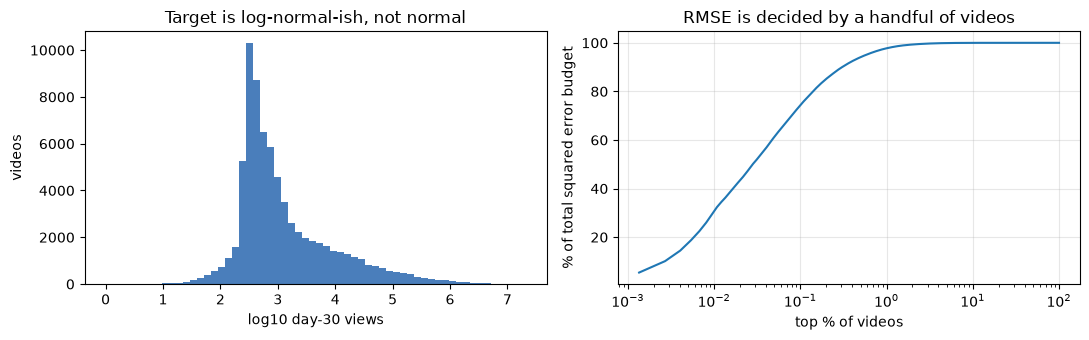

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(np.log10(target.clip(lower=1)), bins=60, color="#4a7ebb")
ax[0].set_xlabel("log10 day-30 views"); ax[0].set_ylabel("videos")
ax[0].set_title("Target is log-normal-ish, not normal")

s = target.sort_values(ascending=False).to_numpy()
ax[1].plot(np.arange(1, len(s) + 1) / len(s) * 100, np.cumsum(s ** 2) / (s ** 2).sum() * 100)
ax[1].set_xscale("log"); ax[1].set_xlabel("top % of videos")
ax[1].set_ylabel("% of total squared error budget")
ax[1].set_title("RMSE is decided by a handful of videos")
ax[1].grid(alpha=.3); plt.tight_layout(); plt.show()

## 2. Features

Everything is derived from days 0–5 only. Three groups:

1. **Trajectory** — the shape of the first five days: levels, daily increments,
   acceleration, growth multipliers, log-slope and curvature.
2. **Video metadata** — duration, topic, music, posting hour, emotion scores.
3. **Context** — creator stats as of the posting date, and how this video compares
   to its creator's / sound's / topic's usual performance.

Engagement *ratios* (shares per view, likes per view) and how they move between
day 1 and day 5 matter more than raw counts: a rising share rate is the classic
pre-viral signal.

In [5]:
early = eng[eng.days_since_post <= CUTOFF]
early = early[early.video_id.isin(target.index)]
panel = early.pivot_table(index="video_id", columns="days_since_post",
                          values=METRICS, aggfunc="last")
panel.columns = [f"{SHORT[m]}_d{d}" for m, d in panel.columns]
for m in METRICS:
    cols = [f"{SHORT[m]}_d{d}" for d in range(CUTOFF + 1)]
    panel[cols] = panel[cols].ffill(axis=1)
print(panel.shape)

(73922, 42)


In [6]:
def trajectory(panel):
    f = pd.DataFrame(index=panel.index)
    f["observed_days"] = panel[[f"play_d{d}" for d in range(CUTOFF + 1)]].notna().sum(axis=1)
    f["has_d0"] = panel["play_d0"].notna().astype(np.int8)
    parts = {}

    for m in METRICS:
        s = SHORT[m]
        cum = panel[[f"{s}_d{d}" for d in range(CUTOFF + 1)]].bfill(axis=1).fillna(0.0)
        cum.columns = list(range(CUTOFF + 1))
        for d in range(CUTOFF + 1):
            parts[f"{s}_d{d}"] = cum[d]
            parts[f"log_{s}_d{d}"] = np.log1p(cum[d])

        inc = pd.DataFrame({d: (cum[d] - cum[d - 1]).clip(lower=0)
                            for d in range(1, CUTOFF + 1)})
        for d in inc.columns:
            parts[f"{s}_inc{d}"] = inc[d]
        parts[f"{s}_inc_mean"] = inc.mean(axis=1)
        parts[f"{s}_inc_std"] = inc.std(axis=1)
        parts[f"{s}_inc_max"] = inc.max(axis=1)
        # still speeding up at the cutoff?
        parts[f"{s}_accel"] = inc[CUTOFF] - inc[CUTOFF - 1]
        parts[f"{s}_inc_share_last"] = inc[CUTOFF] / (cum[CUTOFF] + 1)
        for a, b in [(1, 5), (2, 5), (3, 5), (4, 5), (1, 3), (1, 2)]:
            parts[f"{s}_g{a}{b}"] = np.log1p(cum[b]) - np.log1p(cum[a])
        parts[f"{s}_front_load"] = cum[1] / (cum[CUTOFF] + 1)

        ld = np.log1p(cum[[1, 2, 3, 4, 5]].to_numpy(float))
        xc = np.arange(1, CUTOFF + 1, dtype=float); xc -= xc.mean()
        parts[f"{s}_slope"] = (ld * xc).sum(axis=1) / (xc ** 2).sum()
        parts[f"{s}_curve"] = (ld[:, -1] - ld[:, -2]) - (ld[:, 1] - ld[:, 0])

    f = pd.concat([f, pd.DataFrame(parts, index=panel.index)], axis=1)

    play5 = f["play_d5"]
    extra = {}
    for m in METRICS[1:]:
        s = SHORT[m]
        extra[f"{s}_per_play5"] = f[f"{s}_d5"] / (play5 + 1)
        extra[f"{s}_per_play1"] = f[f"{s}_d1"] / (f["play_d1"] + 1)
        extra[f"{s}_per_play_delta"] = extra[f"{s}_per_play5"] - extra[f"{s}_per_play1"]
    extra["engage_sum5"] = f[[f"{SHORT[m]}_d5" for m in METRICS[1:]]].sum(axis=1)
    extra["engage_rate5"] = extra["engage_sum5"] / (play5 + 1)
    extra["shr_to_like"] = f["shr_d5"] / (f["like_d5"] + 1)
    extra["cmt_to_like"] = f["cmt_d5"] / (f["like_d5"] + 1)
    # naive log-linear extrapolation, bounded because it explodes over 25 days
    extra["extrap_d30"] = (np.log1p(play5) + f["play_slope"] * (30 - CUTOFF)).clip(0, 25)
    return pd.concat([f, pd.DataFrame(extra, index=panel.index)], axis=1)


feat = trajectory(panel)
print(feat.shape)

(73922, 242)


In [7]:
VCOLS = ["video_id", "author_id", "create_time", "create_date", "duration", "ratio",
         "desc_language", "is_english", "created_by_ai", "music_selected_from",
         "music_id", "music_owner_id", "word_count", "emoji_count", "question_count",
         "hashtag_count", "speaking_rate", "topic", "anger", "joy", "surprise",
         "sadness", "disgust", "fear"]
vid = pd.read_csv(RAW / "videos.csv", usecols=VCOLS, low_memory=False)

# is_ads has a single value and enterprise_verified is entirely null -> both useless
ct = pd.to_datetime(vid.create_time, errors="coerce")
vid["hour"], vid["dow"] = ct.dt.hour, ct.dt.dayofweek
vid["day_index"] = (ct - ct.min()).dt.days
vid["create_date"] = pd.to_datetime(vid.create_date, errors="coerce")
vid["has_music_owner"] = vid.music_owner_id.notna().astype(np.int8)
vid["text_missing"] = vid.word_count.isna().astype(np.int8)
EMO = ["anger", "joy", "surprise", "sadness", "disgust", "fear"]
vid["emotion_max"] = vid[EMO].max(axis=1)
vid["emotion_std"] = vid[EMO].std(axis=1)
vid["music_uses"] = vid.groupby("music_id").video_id.transform("count")
vid["author_video_total"] = vid.groupby("author_id").video_id.transform("count")
vid = vid.drop(columns=["create_time", "music_owner_id"]).set_index("video_id")
print(f"{vid.author_id.nunique():,} creators for {len(vid):,} videos")

1,872 creators for 209,543 videos


In [8]:
cre = pd.read_csv(RAW / "creator_daily.csv",
                  usecols=["author_id", "date", "follower_count", "following_count",
                           "total_favorited", "video_count"])
cre["date"] = pd.to_datetime(cre.date, errors="coerce")
cre = cre.dropna(subset=["date"]).sort_values(["author_id", "date"])
cre["fol_7d_ago"] = cre.groupby("author_id").follower_count.shift(7)
cre["fav_7d_ago"] = cre.groupby("author_id").total_favorited.shift(7)
cre = cre.sort_values("date")

key = (vid.reset_index()[["video_id", "author_id", "create_date"]]
          .dropna(subset=["create_date"]).sort_values("create_date"))

# merge_asof with direction=backward -> creator stats as they were ON the posting
# day, never afterwards. This is the guard against look-ahead leakage.
cm = pd.merge_asof(key, cre.drop(columns=["fol_7d_ago", "fav_7d_ago"]),
                   left_on="create_date", right_on="date", by="author_id",
                   direction="backward")
mom = pd.merge_asof(key, cre[["author_id", "date", "fol_7d_ago", "fav_7d_ago"]],
                    left_on="create_date", right_on="date", by="author_id",
                    direction="backward")
cm["fol_growth_7d"] = cm.follower_count - mom.fol_7d_ago
cm["fav_growth_7d"] = cm.total_favorited - mom.fav_7d_ago
cm["fol_growth_rate"] = cm.fol_growth_7d / (cm.follower_count + 1)
cm["fol_per_video"] = cm.follower_count / (cm.video_count + 1)
cm["fav_per_video"] = cm.total_favorited / (cm.video_count + 1)
cm["fol_to_following"] = cm.follower_count / (cm.following_count + 1)
cm["log_follower"] = np.log1p(cm.follower_count.clip(lower=0))
cm = cm.drop(columns=["date", "create_date", "author_id"]).set_index("video_id")
cm.shape

(209543, 11)

### Peer context

A video on 50k views after five days means very different things for a creator who
normally gets 1k and one who normally gets 500k. These aggregates use the whole
209k-video catalogue but only ever read days 0–5, so they stay valid for unseen videos.

In [9]:
e5 = eng[eng.days_since_post <= CUTOFF].groupby("video_id").agg(
    p5=("play_count", "max"), s5=("share_count", "max"))
e5["lp5"] = np.log1p(e5.p5)
cat = vid[["author_id", "music_id", "topic", "create_date"]].join(e5, how="inner")

df = feat.join(vid, how="inner").join(cm, how="left")
m = cat.reindex(df.index)

for tag, col in (("auth", "author_id"), ("mus", "music_id"), ("top", "topic")):
    agg = cat.groupby(col).lp5.agg(["mean", "std", "max", "count"])
    agg.columns = [f"{tag}_lp5_{c}" for c in agg.columns]
    for c in agg.columns:
        df[c] = m[col].map(agg[c]).to_numpy()

lp5 = np.log1p(df.play_d5)
df["vs_auth"] = lp5 - df.auth_lp5_mean
df["vs_auth_max"] = lp5 - df.auth_lp5_max
df["vs_auth_z"] = df.vs_auth / (df.auth_lp5_std + 0.1)
df["vs_music"] = lp5 - df.mus_lp5_mean
df["vs_topic"] = lp5 - df.top_lp5_mean
df["rank_in_auth"] = df.groupby(m.author_id.values).play_d5.rank(pct=True)
df["rank_in_day"] = df.groupby(m.create_date.values).play_d5.rank(pct=True)
df["rank_global"] = df.play_d5.rank(pct=True)
df["days_since_prev"] = (m.create_date - m.create_date.groupby(m.author_id.values).shift(1)).dt.days
# shares outrunning views is the classic pre-viral tell
for s in ("shr", "like", "cmt", "col"):
    df[f"{s}_vs_play_slope"] = df[f"{s}_slope"] - df.play_slope

df["y"] = target.reindex(df.index)
df = df[df.y.notna()].replace([np.inf, -np.inf], np.nan)
print(f"modelling table: {df.shape[0]:,} rows x {df.shape[1]} columns")

modelling table: 73,922 rows x 309 columns


## 3. Hold out a test set

3,001 videos are locked away now and not touched again until the very last cell.

In [10]:
rng = np.random.default_rng(SEED)
test_ids = rng.choice(df.index.to_numpy(), N_TEST, replace=False)
is_test = df.index.isin(test_ids)
tr_df, te_df = df[~is_test], df[is_test]

DROP = ["y", "author_id", "create_date", "music_id"]
X = tr_df.drop(columns=[c for c in DROP if c in tr_df.columns])
Xte = te_df.drop(columns=[c for c in DROP if c in te_df.columns])
# pandas 3 reports text columns as 'str', not 'object'
CATS = [c for c in X.columns if str(X[c].dtype) in ("object", "str", "string")]
for c in CATS:
    levels = pd.Categorical(pd.concat([X[c], Xte[c]]).astype("object")).categories
    X[c] = pd.Categorical(X[c].astype("object"), categories=levels)
    Xte[c] = pd.Categorical(Xte[c].astype("object"), categories=levels)
print("categorical columns:", CATS)

y = tr_df.y.to_numpy(float)
yte = te_df.y.to_numpy(float)
anchor = np.log1p(tr_df.play_d5.to_numpy(float))
anchor_te = np.log1p(te_df.play_d5.to_numpy(float))
print(f"train {len(y):,}   holdout {len(yte):,}")

categorical columns: ['ratio', 'desc_language', 'music_selected_from', 'topic']
train 70,921   holdout 3,001


## 4. Choosing what to predict

The single most important decision in this project, and it is not about the model.

Views are cumulative, so day-30 = day-5 × some multiplier. Predicting that
**multiplier** rather than the level is a far better-conditioned problem: the
multiplier has a median of 1.16 and almost no skew, while the level spans seven
orders of magnitude.

Concretely, fit `log1p(y) − log1p(day5_views)` and add the anchor back afterwards.

In [11]:
LGB = dict(n_estimators=600, learning_rate=0.05, num_leaves=63, min_child_samples=40,
           subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=1.0,
           verbose=-1, n_jobs=-1)
folds = list(KFold(5, shuffle=True, random_state=SEED).split(y))

def cv_oof(fit_y, back, obj="regression", extra=None, weight=None):
    oof = np.zeros(len(y))
    for tr, va in folds:
        m = lgb.LGBMRegressor(**dict(LGB, objective=obj, **(extra or {})))
        w = None if weight is None else weight(y[tr])
        m.fit(X.iloc[tr], fit_y(y[tr], tr), sample_weight=w)
        oof[va] = back(m.predict(X.iloc[va]), va)
    return np.clip(oof, 0, None)

scores = {
    "predict the mean": rmse(y, np.full(len(y), y.mean())),
    "day-5 views as-is": rmse(y, tr_df.play_d5),
    "raw target": rmse(y, cv_oof(lambda t, i: t, lambda p, i: p)),
    "log1p target": rmse(y, cv_oof(lambda t, i: np.log1p(t), lambda p, i: np.expm1(p))),
    "tweedie": rmse(y, cv_oof(lambda t, i: t, lambda p, i: p, "tweedie",
                              {"tweedie_variance_power": 1.5})),
    "growth ratio vs day 5": rmse(y, cv_oof(lambda t, i: np.log1p(t) - anchor[i],
                                            lambda p, i: np.expm1(p + anchor[i]))),
}
pd.Series(scores).sort_values().to_frame("CV RMSE").style.format("{:,.0f}")

,CV RMSE
tweedie,"131,029"
growth ratio vs day 5,"135,099"
raw target,"141,605"
log1p target,"150,248"
day-5 views as-is,"162,811"
predict the mean,"326,999"


## 5. Where the error actually lives

Before tuning anything, find out which videos the score depends on.

In [12]:
ref = cv_oof(lambda t, i: np.log1p(t) - anchor[i], lambda p, i: np.expm1(p + anchor[i]))
dec = pd.qcut(y, 10, labels=False, duplicates="drop")
tab = pd.DataFrame({
    "n": pd.Series(dec).value_counts().sort_index(),
    "mean_true": [y[dec == i].mean() for i in range(10)],
    "rmse": [rmse(y[dec == i], ref[dec == i]) for i in range(10)],
    "share_of_SSE": [((y[dec == i] - ref[dec == i]) ** 2).sum() / ((y - ref) ** 2).sum()
                     for i in range(10)],
})
tab.style.format({"mean_true": "{:,.0f}", "rmse": "{:,.0f}", "share_of_SSE": "{:.1%}"})

,n,mean_true,rmse,share_of_SSE
0,7151,156,17,0.0%
1,7119,281,21,0.0%
2,7008,344,28,0.0%
3,7120,429,44,0.0%
4,7090,573,94,0.0%
5,7071,810,226,0.0%
6,7087,"1,319",347,0.0%
7,7092,"3,116",853,0.0%
8,7091,"10,925","3,181",0.0%
9,7092,"310,167","427,210",100.0%


The top decile owns essentially the entire error budget. The log-ratio fit treats a
300-view video and a 3M-view video as equally important, which is wrong for RMSE.

In log space an error `e` becomes a raw error of roughly `y·e`, so weighting each row
by `y²` makes the log-space fit approximate raw-scale least squares.

In [13]:
for a in [0.0, 0.5, 0.75, 1.0, 1.5, 2.0]:
    o = cv_oof(lambda t, i: np.log1p(t) - anchor[i],
               lambda p, i: np.expm1(p + anchor[i]),
               weight=lambda t, a=a: np.power(np.maximum(t, 1.0), a) /
                                     np.power(np.maximum(t, 1.0), a).mean())
    print(f"weight y^{a:<4}  CV RMSE {rmse(y, o):12,.0f}")

weight y^0.0   CV RMSE      135,099


weight y^0.5   CV RMSE      135,557


weight y^0.75  CV RMSE      128,702


weight y^1.0   CV RMSE      123,321


weight y^1.5   CV RMSE      124,881


weight y^2.0   CV RMSE      121,595


## 6. Ensemble

Five models that fail on different videos. Weights come from non-negative least
squares on out-of-fold predictions, so nothing is fitted on the holdout.

In [14]:
SEEDS = (1, 42, 99)
P = dict(n_estimators=800, learning_rate=0.04, num_leaves=63, min_child_samples=40,
         subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=1.0,
         verbose=-1, n_jobs=-1)

def ratio_model(Xtr, ytr, atr, Xv, av, alpha, seed):
    w = np.power(np.maximum(ytr, 1.0), alpha)
    m = lgb.LGBMRegressor(**dict(P, random_state=seed))
    m.fit(Xtr, np.log1p(ytr) - atr, sample_weight=w / w.mean())
    return np.clip(np.expm1(m.predict(Xv) + av), 0, None)

def level_model(Xtr, ytr, Xv, seed, obj, extra):
    m = lgb.LGBMRegressor(**dict(P, random_state=seed, objective=obj, **extra))
    return np.clip(m.fit(Xtr, ytr).predict(Xv), 0, None)

SPECS = {"ratio_a2": ("ratio", 2.0), "ratio_a075": ("ratio", 0.75),
         "ratio_a0": ("ratio", 0.0),
         "raw_l2": ("level", ("regression", {})),
         "tweedie": ("level", ("tweedie", {"tweedie_variance_power": 1.5}))}

def build(spec, Xtr, ytr, atr, Xv, av):
    kind, cfg = spec
    if kind == "ratio":
        return np.mean([ratio_model(Xtr, ytr, atr, Xv, av, cfg, s) for s in SEEDS], axis=0)
    return np.mean([level_model(Xtr, ytr, Xv, s, cfg[0], cfg[1]) for s in SEEDS], axis=0)

oof = {k: np.zeros(len(y)) for k in SPECS}
for tr, va in folds:
    for k, spec in SPECS.items():
        oof[k][va] = build(spec, X.iloc[tr], y[tr], anchor[tr], X.iloc[va], anchor[va])

keys = list(SPECS)
A = np.column_stack([oof[k] for k in keys])
w, _ = nnls(A, y)
print(f"blend CV RMSE {rmse(y, np.clip(A @ w, 0, None)):,.0f}\n")
for k, wi in zip(keys, w):
    print(f"  {k:12} cv={rmse(y, oof[k]):11,.0f}   weight={wi:.3f}")

blend CV RMSE 117,526

  ratio_a2     cv=    122,347   weight=0.451
  ratio_a075   cv=    127,501   weight=0.187
  ratio_a0     cv=    133,527   weight=0.000
  raw_l2       cv=    141,625   weight=0.225
  tweedie      cv=    131,913   weight=0.158


### How noisy is this number?

Worth knowing before trusting any small improvement.

In [15]:
per_fold = [rmse(y[va], np.clip(A @ w, 0, None)[va]) for _, va in folds]
print("per-fold RMSE:", "  ".join(f"{v:,.0f}" for v in per_fold))
print(f"mean {np.mean(per_fold):,.0f}   sd {np.std(per_fold):,.0f}")
print("\nDifferences smaller than roughly the sd are noise, not improvement.")

per-fold RMSE: 78,909  162,964  88,031  95,664  139,201
mean 112,954   sd 32,463

Differences smaller than roughly the sd are noise, not improvement.


## 7. Final evaluation on the untouched holdout

In [16]:
B = np.column_stack([build(SPECS[k], X, y, anchor, Xte, anchor_te) for k in keys])
pred = np.maximum(np.clip(B @ w, 0, None), np.expm1(anchor_te))  # never below day-5

r2 = lambda t, q: 1 - ((t - q) ** 2).sum() / ((t - t.mean()) ** 2).sum()
ape = np.abs(pred - yte) / np.maximum(yte, 1)
rat = np.maximum(pred, 1) / np.maximum(yte, 1)
top = yte >= np.quantile(yte, 0.99)

print(f"HOLDOUT RMSE          {rmse(yte, pred):12,.0f}")
print(f"  vs predict-the-mean {rmse(yte, np.full(len(yte), y.mean())):12,.0f}")
print(f"  vs day-5 baseline   {rmse(yte, te_df.play_d5):12,.0f}")
print(f"  R2 (raw)            {100 * r2(yte, pred):11.1f}%")
print(f"  R2 (log)            {100 * r2(np.log1p(yte), np.log1p(pred)):11.1f}%")
print(f"  Spearman            {100 * spearmanr(yte, pred).statistic:11.1f}%")
print(f"  median abs % error  {100 * np.median(ape):11.1f}%")
print(f"  within 2x           {100 * np.mean((rat <= 2) & (rat >= .5)):11.1f}%")
print(f"  top 1%: median err  {100 * np.median(ape[top]):11.1f}%"
      f"   within 2x {100 * np.mean((rat[top] <= 2) & (rat[top] >= .5)):.0f}%")

HOLDOUT RMSE                63,605
  vs predict-the-mean      243,652
  vs day-5 baseline        129,905
  R2 (raw)                   93.2%
  R2 (log)                   21.1%
  Spearman                   72.8%
  median abs % error        264.0%
  within 2x                  32.5%
  top 1%: median err         15.9%   within 2x 87%


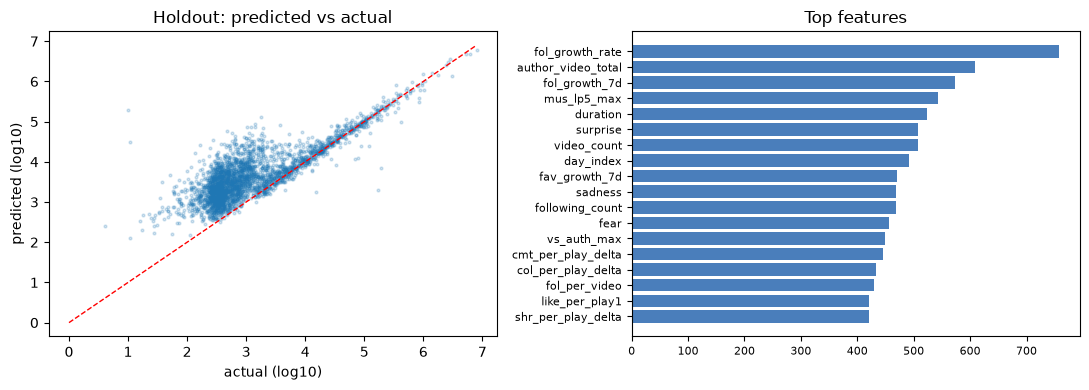

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(np.log10(np.maximum(yte, 1)), np.log10(np.maximum(pred, 1)), s=4, alpha=.2)
lim = [0, np.log10(max(yte.max(), pred.max()))]
ax[0].plot(lim, lim, "r--", lw=1)
ax[0].set_xlabel("actual (log10)"); ax[0].set_ylabel("predicted (log10)")
ax[0].set_title("Holdout: predicted vs actual")

imp = pd.Series(lgb.LGBMRegressor(**dict(P, random_state=1)).fit(
    X, np.log1p(y) - anchor,
    sample_weight=np.power(np.maximum(y, 1), 2) / np.power(np.maximum(y, 1), 2).mean()
).feature_importances_, index=X.columns).nlargest(18)[::-1]
ax[1].barh(imp.index, imp.values, color="#4a7ebb")
ax[1].set_title("Top features"); ax[1].tick_params(labelsize=8)
plt.tight_layout(); plt.show()

In [18]:
sub = pd.DataFrame({"video_id": te_df.index.astype("int64"),
                    "target_day30_views": pred})
Path("submissions").mkdir(exist_ok=True)
sub.to_csv("submissions/submission.csv", index=False)
print(f"wrote submissions/submission.csv  ({len(sub):,} rows)")
sub.head()

wrote submissions/submission.csv  (3,001 rows)


,video_id,target_day30_views
0,7384196269301927198,1771.950785
1,7384201681162079518,848.743749
2,7384205838946159902,4888.150117
3,7384209153692126507,10990.923280
4,7384210748752366891,5487.901408


## What did not work

Kept deliberately, because the failures are as informative as the wins.

| attempt | result | why |
|---|---|---|
| Creator history encoding | **much worse** (134k vs 120k) | virality is video-specific, not creator-specific — a creator's past growth does not transfer |
| Duan smearing on the log model | worse | the ratio parametrisation already removes most of the retransformation bias |
| Exact raw-L2 custom objective | diverged | the `exp(2z)` Hessian explodes on 7-figure targets |
| Tail-specialist model | worse on its own segment | training on 10% of rows loses more than the specialisation gains |
| Capping sample weights | worse | the capped videos are exactly the ones RMSE cares about |
| Segment-wise blend weights | inside noise | gain smaller than fold-to-fold variation |

## Honest limitations

- **13 videos out of 73,922 carry 37% of all squared error.** They were small at day 5
  and exploded later. Nothing in days 0–5 distinguishes them, so that error is
  largely irreducible.
- **Per-fold RMSE ranges 90k–141k.** Any single score is dominated by whether a freak
  video landed in that split.
- The model is deliberately poor on small videos (median error ~150%) because they
  contribute nothing to RMSE. Under a percentage-error metric the design would be different.